# Quadrature in PySPIDER

This tutorial follows `01_Continuous.ipynb` through the same Taylor–Green data model, library construction, regression, and output analysis. It first introduces the quadrature rules, then changes the continuous example's **x sampling** to a Chebyshev–Gauss grid and integrates its subdomains with `truncated-cg-grid`.

The Taylor–Green example keeps the continuous notebook's domain lengths, 256×256×128 data shape, random seed, four irreducible representations, library constraints, 50 integration domains of 40×40×20 samples, m=12 weights, and regression settings. Only sampling, quadrature configuration, and the plot's treatment of nonuniform coordinates differ. Integration domains have different physical x widths depending on their location in the Gauss grid.

Run the cells in order with PySPIDER and Matplotlib installed. The full example has the same substantial data size as the continuous tutorial; matrix construction and regression are the longest steps. This notebook requires NumPy 2.x for the current integrator's `np.trapezoid` calls.

### Imports

The next cell locates the repository’s `src` directory so the tutorial uses your local PySPIDER implementation. Start Jupyter from the repository or its `tutorials` directory.

In [1]:
import sys
from pathlib import Path

# Find the src layout whether Jupyter starts in tutorials/ or the repository root.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'src' / 'PySPIDER').is_dir():
        sys.path.insert(0, str(candidate / 'src'))
        break
else:
    raise RuntimeError('Start Jupyter in the PySPIDER repository or its tutorials directory.')

We will use numpy to generate the dataset and matplotlib for plotting. SciPy is only used here for an independent reference integral.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


The SPIDER-specific pieces for this tutorial are the Observable and SRDataset objects (as in the continuous tutorial), plus the quadrature helpers in `commons.quadrature_schemes` and the integrator `int_arr`.


In [11]:
from PySPIDER.commons.library import Observable
from PySPIDER.commons.integration import int_arr
from PySPIDER.commons.quadrature_schemes import (
    mapped_chebyshev_nodes,
    mapped_chebyshev_gauss_nodes,
    truncated_chebyshev_gauss_nodes,
    clenshaw_curtis_weights,
    chebyshev_gauss_weights,
)
from PySPIDER.continuous.process_library_terms import SRDataset


### Why quadrature matters for SPIDER

SPIDER's weak-form integrals are evaluated by `int_arr`. By default every axis uses the composite trapezoidal rule, which is a good match for uniform grids. Spectral and many simulation grids are *not* uniform: Chebyshev-Lobatto grids include the endpoints, while Chebyshev-Gauss grids use the interior roots of $T_n$. Using the wrong rule on the wrong nodes can stall accuracy even when the field looks smooth.

This notebook mirrors the continuous Taylor-Green workflow, but samples one spatial axis on a Chebyshev-Gauss grid and wires the matching quadrature scheme through `SRDataset`.


### Selecting a rule

| Scheme | Samples required | Typical use |
| --- | --- | --- |
| `trapezoidal` | Uniform samples for the index-space convention | Default axes; legacy results |
| `clenshaw-curtis` | Complete mapped Lobatto grid, including endpoints | Full spectral axes |
| `chebyshev-gauss` | Complete mapped first-kind Gauss grid, interior nodes | Full spectral axes (Fejér-I weights) |
| `truncated-cc-grid` | Subset of a parent Lobatto grid | Integration windows in a Lobatto-sampled field |
| `truncated-cg-grid` | Subset of a parent Gauss grid | Integration windows in a Gauss-sampled field |
| `moment-matching` | Explicit arbitrary nodes with a suitable matching degree | Other known sampling grids; see the conditioning guidance below |

`int_arr`'s trapezoidal rule integrates in grid-index units, as in the original implementation. Spectral rules include the Jacobian for their specified interval. Supply the same interval when comparing spectral rules, and use coordinate-aware `np.trapezoid(values, x=nodes)` for a physical-unit trapezoidal comparison.

### Chebyshev-Lobatto vs Chebyshev-Gauss nodes

Mapped Lobatto nodes come from `mapped_chebyshev_nodes` (extrema of $T_N$, including the endpoints). Mapped Gauss nodes come from `mapped_chebyshev_gauss_nodes` (roots of $T_n$, interior only). Clenshaw-Curtis weights pair with Lobatto; Fejer-I / DCT-III weights pair with Gauss. Both weight families are built from analytic Chebyshev moments of the (optional) SPIDER weight polynomial.


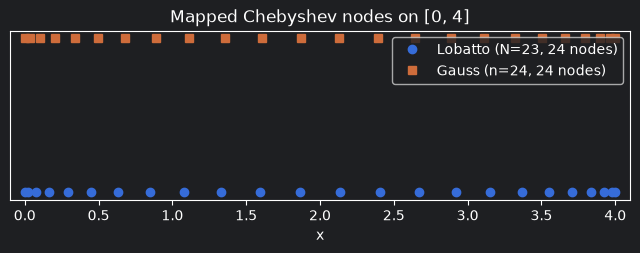

Lobatto endpoints: 0.0 4.0
Gauss interior range: 0.004282153522793042 3.995717846477207


In [12]:
n_lob, n_gauss = 23, 24
a, b = 0.0, 4.0
x_lob = mapped_chebyshev_nodes(n_lob, a, b)           # n_lob intervals -> n_lob+1 nodes
x_gauss = mapped_chebyshev_gauss_nodes(n_gauss, a, b)   # n_gauss nodes

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.plot(x_lob, np.zeros_like(x_lob), 'o', label=f'Lobatto (N={n_lob}, {len(x_lob)} nodes)')
ax.plot(x_gauss, np.ones_like(x_gauss) * 0.15, 's', label=f'Gauss (n={n_gauss}, {len(x_gauss)} nodes)')
ax.set_yticks([])
ax.set_xlabel('x')
ax.set_xlim(a - 0.1, b + 0.1)
ax.legend(loc='upper right')
ax.set_title('Mapped Chebyshev nodes on [0, 4]')
plt.show()

print('Lobatto endpoints:', float(x_lob[0]), float(x_lob[-1]))
print('Gauss interior range:', float(x_gauss[0]), float(x_gauss[-1]))

### Integrating with `int_arr`

`int_arr` takes an array and a per-axis scheme map. Omitted axes default to trapezoidal. For a full Chebyshev-Gauss axis, pass `"chebyshev-gauss"` (optionally with `interval` and `nodes`). The same pattern with `"clenshaw-curtis"` selects Lobatto / Clenshaw-Curtis.


In [13]:
# Compare physical integrals of x^4 on [0, 4]; exact = 4^5 / 5 = 204.8.
a, b = 0.0, 4.0
x = mapped_chebyshev_gauss_nodes(32, a, b)
f = x**4
full_gauss = {0: {"chebyshev-gauss": {"interval": [a, b], "nodes": x}}}
gauss_est = float(int_arr(f, full_gauss))
# Gauss nodes exclude the endpoints, so include exact endpoint samples for
# this separate physical trapezoidal baseline over the same complete interval.
x_trap = np.concatenate(([a], x, [b]))
trap_est = float(np.trapezoid(x_trap**4, x=x_trap))
exact = (b**5-a**5)/5
print(f'exact             = {exact:.12g}')
print(f'Gauss / Fejer-I    = {gauss_est:.12g}, error = {abs(gauss_est-exact):.3e}')
print(f'physical trapezoid= {trap_est:.12g}, error = {abs(trap_est-exact):.3e}')
np.testing.assert_allclose(gauss_est, exact, rtol=1e-11)

exact             = 204.8
Gauss / Fejer-I    = 204.8, error = 5.684e-14
physical trapezoid= 205.292847617, error = 4.928e-01


Matching the scheme to the nodes is essential. Applying Clenshaw-Curtis (Lobatto weights) to Gauss samples — or the reverse — either raises a clear error when `nodes` are supplied, or silently loses accuracy if the wrong rule is inferred from array length alone.


In [14]:
# Explicit node checks: a full rule requires its own node family.
try:
    int_arr(f, {0: {"clenshaw-curtis": {"interval": [a, b], "nodes": x}}})
except ValueError as e:
    print('Clenshaw-Curtis on Gauss nodes:', e)

x_lob = mapped_chebyshev_nodes(31, a, b)
try:
    int_arr(x_lob**4, {0: {"chebyshev-gauss": {"interval": [a, b], "nodes": x_lob}}})
except ValueError as e:
    print('Gauss rule on Lobatto nodes:', e)

# Omitting nodes asks int_arr to assume the selected node family.
# Keep the interval identical so this comparison isolates the node mismatch.
wrong = float(int_arr(f, {0: {"clenshaw-curtis": {"interval": [a, b]}}}))
right = float(int_arr(f, {0: {"chebyshev-gauss": {"interval": [a, b]}}}))
print(f'Inferred Lobatto rule on Gauss samples: error = {abs(wrong-exact):.3e}')
print(f'Inferred Gauss rule on Gauss samples:   error = {abs(right-exact):.3e}')
np.testing.assert_allclose(right, exact, rtol=1e-11)

Clenshaw-Curtis on Gauss nodes: clenshaw-curtis needs the full mapped Lobatto grid on [0.0, 4.0]
Gauss rule on Lobatto nodes: chebyshev-gauss needs the full mapped Gauss grid on [0.0, 4.0]
Inferred Lobatto rule on Gauss samples: error = 6.306e+00
Inferred Gauss rule on Gauss samples:   error = 5.684e-14


### Generating the dataset

To test SPIDER, let's generate a [Taylor-Green vortex](https://en.wikipedia.org/wiki/Taylor%E2%80%93Green_vortex) solution $\{p(x, y, t), {\bf u}(x, y, t)\}$ in two spatial dimensions with a kinematic viscosity $\nu = 0.01$. It should satisfy the Navier-Stokes equation $$\partial_t {\bf u} + ({\bf u} \cdot \nabla) {\bf u} + \nabla p - \nu \nabla^2 {\bf u}  = 0$$ as well as the incompressibility condition $$\nabla \cdot {\bf u} = 0.$$ Let's see which equations SPIDER will find.
We keep the same viscosity, fields, resolutions, and physical domain. The x coordinates below are the one sampling change: a mapped Chebyshev–Gauss grid. The y and t arrays remain identical to the continuous example. `indexing='ij'` ensures pressure has axes (x,y,t) when x and y use different nodes.


In [15]:
Lx = 4; Ly = 4; Lt = 1
Nx = 256; Ny = Nx; Nt = 128  # identical resolutions to 01_Continuous.ipynb
dx = Lx/Nx; dy = Ly/Ny; dt = Lt/Nt

x = mapped_chebyshev_gauss_nodes(Nx, 0.0, Lx)  # quadrature-specific sampling
y = np.arange(0, 4, dy); t = np.arange(0, 1, dt)
xg, yg = np.meshgrid(x, y, indexing='ij')
U = 4*np.einsum('i,j,k->ijk', np.sin(4*x), np.cos(4*y), np.exp(-0.64*t))
V = -4*np.einsum('i,j,k->ijk', np.cos(4*x), np.sin(4*y), np.exp(-0.64*t))

P = 4*np.einsum('ij,k->ijk', np.cos(8*xg)+np.cos(8*yg), np.exp(-1.28*t))
u = np.concatenate([U[:, :, :, np.newaxis], V[:, :, :, np.newaxis]], axis=3)

The data are formatted as numpy arrays with axes (x, y, t), followed by optional axes for each component of the observable. For instance, the scalar pressure is represented by P, a 3D array with axes (x, y, t), whereas the vector flow velocity is stored in a 4D with an additional axis corresponding to the component (x or y).

In [9]:
P.shape, u.shape

((256, 256, 128), (256, 256, 128, 2))

The square spatial domain is periodically tiled by rotationally symmetric vortices, which decay exponentially over time:

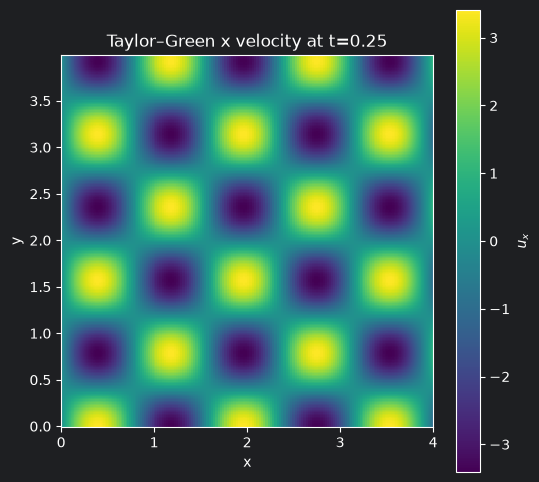

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.pcolormesh(x, y, U[:, :, 32].T, shading='auto')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_title(f'Taylor–Green x velocity at t={t[32]:.2f}')
fig.colorbar(im, ax=ax, label=r'$u_x$')
plt.show()

### Defining and evaluating SPIDER objects

Next, let's define Observable objects representing the scalar field $p$ and vector field ${\bf u}$ and create a mapping from the observable names to the numpy data arrays.

In [17]:
pobs = Observable(string='p', rank=0)
uobs = Observable(string='u', rank=1)
observables = [uobs, pobs]
data_dict = {'p': P, 'u': u}

uobs, pobs # the string representation shows where the indices of the tensor can go

(u_{ }, p)

It is also possible to define rank-2 tensor-valued observables. However, we will not use these in the present tutorial.

In [18]:
A = Observable(string='A', rank=2) # second-rank tensor observable with no special properties
A_sym = Observable(string='A', rank=2, can_commute_indices=True) # a symmetric second-rank tensor
# finally, an antisymmetric second-rank tensor
A_antisym = Observable(string='A', rank=2, can_commute_indices=True, antisymmetric=True) 

A # again, we can print out the Observable

A_{ }{ }

Now finish setting up the dataset as in the continuous notebook. `grids=[x, None, None]` supplies the actual nonuniform x coordinates; the nominal `dx=Lx/Nx` is not used to differentiate that axis. The y and t spacings are unchanged.

Because the integration domains will contain only 40 of the 256 x samples, select `truncated-cg-grid`, not the full-grid Gauss rule. With `grids` supplied and no explicit node/interval options, PySPIDER uses each domain's actual x slice and its endpoint interval. This allows one dataset to contain many subdomains with different physical widths.

In [19]:
world_size = np.array(P.shape)  # dimensions of the dataset in grid points
dxs = [dx, dy, dt]              # grids supplies the true nonuniform x coordinates

np.random.seed(1)  # same reproducible domain sampling as the continuous tutorial
srd = SRDataset(
    world_size=world_size, data_dict=data_dict, observables=observables, dxs=dxs,
    grids=[x, None, None],
    schemes_and_options={0: "truncated-cg-grid"},
    irreps=SRDataset.all_rank2_irreps(), cache_primes=True,
)

The irreps parameter represents the irreducible representations of the rotational symmetry group $O(n)$ to use for model discovery. Here we use the default value, which constructs separate libraries corresponding to scalar, vector, antisymmetric rank-2, and trace-free symmetric rank-2 equations. (For the rank-2 irreducible representations, the terms and equations that are output implicitly include the projection onto the correct subspace.)

cache_primes=True allows us to cache some of the library evaluation results. To save memory, it is possible to switch this to False, at the cost of a substantial slowdown of library evaluation.

The next step is always to construct the libraries. By default, SPIDER just generates all terms up to a complexity threshold, but we can also ask for additional constraints. Note that the string representation of all symbolic objects uses Einstein notation.

In [20]:
srd.make_libraries(max_complexity=4)
for irrep in srd.irreps:
    print(f"The {irrep} library has {len(srd.libs[irrep].terms)} terms:")
    print(srd.libs[irrep].terms)
    print()

The Rank 0 library has 43 terms:
[p, p · p, p · p · p, p · p · p · p, p · p · ∂t p, p · p · u_α · u_α, p · p · ∂α u_α, p · ∂α p · u_α, p · ∂α² p, p · ∂t p, p · ∂t² p, p · u_α · u_α, p · u_α · ∂t u_α, p · ∂α u_α, p · ∂t ∂α u_α, ∂α p · ∂α p, ∂α p · u_α, ∂α p · ∂t u_α, ∂α² p, ∂t p, ∂t p · ∂t p, ∂t p · u_α · u_α, ∂t p · ∂α u_α, ∂t ∂α p · u_α, ∂t ∂α² p, ∂t² p, ∂t³ p, u_α · u_α, u_α · u_α · u_β · u_β, u_α · u_β · ∂α u_β, u_α · u_α · ∂β u_β, u_α · ∂α ∂β u_β, u_α · ∂β² u_α, u_α · ∂t u_α, u_α · ∂t² u_α, ∂α u_α, ∂α u_β · ∂β u_α, ∂α u_β · ∂α u_β, ∂α u_α · ∂β u_β, ∂α² ∂β u_β, ∂t u_α · ∂t u_α, ∂t ∂α u_α, ∂t² ∂α u_α]

The Rank 1 library has 51 terms:
[p · p · p · u_α, p · p · ∂α p, p · p · u_α, p · p · ∂t u_α, p · ∂α p, p · ∂t p · u_α, p · ∂t ∂α p, p · u_α, p · u_α · u_β · u_β, p · u_β · ∂α u_β, p · u_α · ∂β u_β, p · u_β · ∂β u_α, p · ∂β² u_α, p · ∂α ∂β u_β, p · ∂t u_α, p · ∂t² u_α, ∂α p, ∂α p · ∂t p, ∂α p · u_β · u_β, ∂β p · u_α · u_β, ∂α p · ∂β u_β, ∂β p · ∂α u_β, ∂β p · ∂β u_α, ∂β² p · u_α, ∂α ∂β

Let's illustrate constraining the libraries a bit.

In [21]:
max_observable_counts = {pobs: 1, uobs: 999} # we don't want p to appear in any term more than once, but u is fine 
# let's say we also don't want time derivatives of order higher than 1 or spatial derivatives higher than 2
srd.make_libraries(max_complexity=4, max_observable_counts=max_observable_counts,
                   max_dt=1, max_dx=2) 
# Another parameter you can use is max_observables for max total number of observables in one term

for irrep in srd.irreps:
    print(f"The {irrep} library now has {len(srd.libs[irrep].terms)} terms:")
    print(srd.libs[irrep].terms)
    print()

The Rank 0 library now has 26 terms:
[p, p · u_α · u_α, p · u_α · ∂t u_α, p · ∂α u_α, p · ∂t ∂α u_α, ∂α p · u_α, ∂α p · ∂t u_α, ∂α² p, ∂t p, ∂t p · u_α · u_α, ∂t p · ∂α u_α, ∂t ∂α p · u_α, ∂t ∂α² p, u_α · u_α, u_α · u_α · u_β · u_β, u_α · u_α · ∂β u_β, u_α · u_β · ∂α u_β, u_α · ∂α ∂β u_β, u_α · ∂β² u_α, u_α · ∂t u_α, ∂α u_α, ∂α u_β · ∂α u_β, ∂α u_α · ∂β u_β, ∂α u_β · ∂β u_α, ∂t u_α · ∂t u_α, ∂t ∂α u_α]

The Rank 1 library now has 37 terms:
[p · u_α, p · u_α · u_β · u_β, p · u_β · ∂β u_α, p · u_β · ∂α u_β, p · u_α · ∂β u_β, p · ∂β² u_α, p · ∂α ∂β u_β, p · ∂t u_α, ∂α p, ∂β p · u_α · u_β, ∂α p · u_β · u_β, ∂α p · ∂β u_β, ∂β p · ∂β u_α, ∂β p · ∂α u_β, ∂α ∂β p · u_β, ∂β² p · u_α, ∂t p · u_α, ∂t p · ∂t u_α, ∂t ∂α p, u_α, u_α · u_β · u_β, u_β · u_β · ∂t u_α, u_α · u_β · ∂t u_β, u_β · ∂α u_β, u_β · ∂β u_α, u_α · ∂β u_β, u_β · ∂t ∂α u_β, u_α · ∂t ∂β u_β, u_β · ∂t ∂β u_α, ∂β u_α · ∂t u_β, ∂β u_β · ∂t u_α, ∂α u_β · ∂t u_β, ∂β² u_α, ∂α ∂β u_β, ∂t u_α, ∂t ∂β² u_α, ∂t ∂α ∂β u_β]

The Antisymmetric r

The next step is to construct the integration domains and scalar weight functions. SPIDER will automatically convert the scalar weights into tensor-valued ones when evaluating the non-scalar irreducible representations.
Use exactly the same 50 domains of 40×40×20 samples and m=12, qmax=0 weights as the continuous tutorial. The physical x half-width varies across domains because the sample spacing is nonuniform. PySPIDER maps each weight onto that domain and converts its kth derivative with H**(-k), where H is the physical support half-width. The shared weight object is a template; evaluation resolves the scale per domain.


In [24]:
# make 50 domains that are 40x40x20 grid points
dom_width = 40
dom_time = 20
srd.make_domains(ndomains=50, domain_size=[dom_width, dom_width, dom_time], pad=0)
# pad>0 would ensure a distance of pad grid points between the domain and the edge of the dataset

# We can display the corner coordinates of some of these. Note that rerunning this cell will resample the domains!
print(srd.domains[0:5])

# m is the envelope exponent in the weight function (usually doesn't need to be tuned)
# qmax is the max degree of Legendre polynomial to use in the weight functions:
# this lets us construct (qmax+1)^3 independent weight functions per integration domain
# additionally, you can constraint to even/odd weight functions by setting `symmetry` to "even" or "odd"
# finally, you can instead specify qmax_list for different max degrees along each dimension or q_lists for a nested list of polynomials to use along each dimension 
srd.make_weights(m=12, qmax=0)

# With the default value, there is only one weight function.
# q indexes the Legendre polynomial, k is the derivative order applied to the weight function, 
# coeff is a constant scaling factor, and dxs contains the physical support half-widths of the template domain.
# Don't worry too much about all of the attributes - they are handled automatically.
print(srd.weights)

[IntegrationDomain([130, 103, 98], [169, 142, 117]), IntegrationDomain([10, 182, 96], [49, 221, 115]), IntegrationDomain([82, 214, 70], [121, 253, 89]), IntegrationDomain([194, 71, 103], [233, 110, 122]), IntegrationDomain([176, 54, 15], [215, 93, 34])]
[Weight(m=[12, 12, 12], q=[0, 0, 0], k=[0, 0, 0], coeff=1, dxs=[0.4568753569717994, 0.3046875, 0.07421875])]


Finally, it is important to estimate the characteristic length and time scales of the dataset, which inform the physical nondimensionalization of all of the terms. The correlation length/time are often a good guess, and it's usually sufficient to be within the right order of magnitude.

Once they are set, we can construct the library matrices. (Setting debug=True will output a ton of debug info!)

In [23]:
srd.set_LT_scale(L=1, T=1) # note that this line must go before make_library_matrices
# this takes a few seconds to run but can be accelerated by using parallel processing!
srd.make_library_matrices(debug=False, parallel=True, num_processors=2)

for irrep in srd.irreps:
    print(f"{irrep} library matrix shape: {srd.libs[irrep].Q.shape}")
for irrep in srd.irreps:
    assert np.isfinite(srd.libs[irrep].Q).all(), f"Non-finite matrix for {irrep}"


Rank 0 library matrix shape: (50, 26)
Rank 1 library matrix shape: (100, 37)
Antisymmetric rank 2 library matrix shape: (50, 18)
Symmetric trace-free rank 2 library matrix shape: (100, 29)


### Regression

Now that the library matrices have been computed, SPIDER can solve the regression problem. We declare regression options for each irreducible representation, and SPIDER iteratively finds all of the equations within all of these.

In [25]:
from PySPIDER.commons.identify_models import interleave_identify
from PySPIDER.commons.sparse_reg_bf import Scaler, Initializer, ModelIterator, Threshold, Residual


reg_opts_list = []
for irrep in srd.irreps:
    # for regression we need to construct Scaler, Initializer, ModelIterator, and Threshold objects
    scaler = Scaler(sub_inds=None, char_sizes=srd.libs[irrep].col_weights, row_norms=None, unit_rows=True, train_fraction=0.8)
    # the Scaler deals with nondimensionalization of the library matrix
    # sub_inds=None: (initially) retain all of the columns in the library
    # char_sizes: nondimensionalization of each column by its characteristic size
    # row_norms: rescaling of the rows of the library matrix, if supplied
    # unit_rows=True: independently normalize each row to O(1)
    # train_fraction=0.8: train/test split of 0.8 to 0.2

    # the Initializer declares the method for initializing the initial guess for the solution
    # and the ModelIterator sets options for the greedy backward-forward regression iteration
    # try a few different combinations!

    # option 1: compute initial k=10 guess via truncated inverse iteration
    init = Initializer(method='power', start_k=10) 
    # complete up to 3 backward-forward passes over 1<=k<=10
    iterator = ModelIterator(max_k=10, backward_forward=True, max_passes=3) 

    # option 2: compute initial guess by combinatorial search over all 2-term relations
    #init = Initializer(method='combinatorial', start_k=2)
    #iterator = ModelIterator(max_k=10, backward_forward=True, max_passes=3) 

    # option 3: include all terms in the initial guess support
    #init = Initializer(method='combinatorial', start_k=len(srd.libs[irrep].terms))
    # complete only one backward elimination pass
    #iterator = ModelIterator(max_k=len(srd.libs[irrep].terms), backward_forward=False, max_passes=1)

    # the Residual object represents the residual type used for quantifying solution accuracy
    res = Residual(residual_type='matrix_relative') # Frobenius residual
    # other options: 'absolute' residual, 'hybrid' (used for error reporting only, Frobenius used for support selection),
    # and 'dominant balance' (dominant term residual)

    # the Threshold is used for selecting the final sparsity of the relation; we provide two examples here:
    # jump criterion: gamma=1.5, and continue to remove terms until r>delta
    # setting n_terms will fix k
    thres = Threshold(threshold_type='jump', gamma=1.5, delta=1e-8, n_terms=None)
    # information criterion
    #thres = Threshold(threshold_type='information', ic=AIC)
    
    # put everything together into an options dictionary
    opts = {'scaler': scaler, 'initializer': init, 'residual': res,
            'model_iterator': iterator, 'threshold': thres}
    opts['verbose'] = False # setting to True outputs all of the debug info
    # setting to True and specifying a column number will perform inhomogeneous regression with
    # that column on the right-hand side
    opts['inhomog'] = False 
    opts['inhomog_col'] = None
    reg_opts_list.append(opts)

# now we can run the regression
eqs, lambdas, reg_results, derived_eqs, excluded_terms = interleave_identify([srd.libs[i] for i in srd.irreps], 
reg_opts_list, threshold=1e-6, report_accuracy=True)
# threshold is the max residual threshold (r_max) at which equations are accepted
# report_accuracy reports the hybrid residual r_h as well
# additional options: max_equations - halt once max_equations have been output

--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 2 ---
[0.01 s]
Identified model: ∂α u_α = 0 (order 2, train res 6.22e-09, test res 2.11e-08)
[0.24 s]
Identified model: p + 0.781 · ∂t p = 0 (order 2, train res 5.90e-14, test res 3.80e-14)
(r_h = 1.72e-13)
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 2 ---
[0.00 s]
Identified model: 0.64 · u_α + ∂t u_α = 0 (order 2, train res 5.15e-14, test res 8.79e-15)
(r_h = 4.11e-13)
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 3 ---
[0.00 s]
Identified model: p + 0.0156 · ∂α² p = 0 (order 3, tra

/Users/patricko/Projects/PySPIDER/src/PySPIDER/commons/sr_utils.py:77: ComplexWarning: Casting complex values to real discards the imaginary part
  x[inds] = smallest_eig(A[np.ix_(inds, inds)])  # work on submatrix with inds


Interpret the identified equations as in the continuous tutorial. Useful relations to look for are:

1. Incompressibility: $\partial_\alpha u_\alpha=0$.
2. Taylor–Green-specific identities, including $\partial_t p+1.28p=0$ and $\partial_t u_\alpha+0.64u_\alpha=0$.
3. The decoupled Navier–Stokes balances $\nabla p+({\bf u}\cdot\nabla){\bf u}=0$ and $\partial_t{\bf u}-0.01\nabla^2{\bf u}=0$.

Equation ordering, the equivalent basis of discovered relations, and residuals can differ from the uniform-grid notebook. Inspect the printed train/test residuals and coefficients; nonuniform quadrature does not by itself guarantee machine-precision recovery. A relation may appear as an implication of earlier equations rather than a separate fundamental equation.

The next cell follows the continuous notebook's second regression run with copyable LaTeX output. Reset the scalers first because they retain exclusions from the previous run.

In [26]:
for i, irrep in enumerate(srd.irreps): 
    reg_opts_list[i]['scaler'].reset_inds(list(range(len(srd.libs[irrep].terms))))

eqs, lambdas, reg_results, derived_eqs, excluded_terms = interleave_identify([srd.libs[i] for i in srd.irreps], 
reg_opts_list, threshold=1e-6, report_accuracy=True,
print_opts={'num_format': '{0:.3g}', 'latex_output': True})

--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 2 ---
[0.00 s]
Identified model: \partial_\alpha u_{\alpha} = 0 (order 2, train res 6.22e-09, test res 2.11e-08)
[0.24 s]
Identified model: p + 0.781 \cdot \partial_t p = 0 (order 2, train res 5.90e-14, test res 3.80e-14)
(r_h = 1.72e-13)
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 2 ---
[0.00 s]
Identified model: 0.64 \cdot u_{\alpha} + \partial_t u_{\alpha} = 0 (order 2, train res 5.15e-14, test res 8.79e-15)
(r_h = 4.11e-13)
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 3 ---
[0.00

### Analyzing outputs

Besides the printed outputs, various information is saved to the output variables.

In [27]:
eqs # fundamental equations

[∂α u_α,
 p + 0.7812499997591882 · ∂t p,
 0.6400000001991605 · u_α + ∂t u_α,
 p + 0.01562499980036353 · ∂α² p,
 0.9999999988601864 · ∂α p + u_β · ∂β u_α,
 u_α + 0.03124999567998393 · ∂β² u_α,
 p + -0.01562500003874581 · ∂α u_β · ∂β u_α,
 p · u_α + 0.031250001172627585 · ∂β p · ∂β u_α,
 ∂α u_γ · ∂γ u_β,
 ∂α p · u_β + -0.9999999728658892 · u_α · u_γ · ∂β u_γ + -0.9999999327181789 · u_γ · u_γ · ∂α u_β,
 ∂α u_γ · ∂γ u_β,
 -0.031250000055664806 · ∂α ∂β p + u_α · u_β + 0.03125000025231685 · ∂γ u_α · ∂γ u_β,
 -0.03125000005487943 · ∂α ∂β p + u_α · u_β + -0.03125000025231686 · ∂α u_γ · ∂β u_γ,
 -0.031249997883604993 · ∂α ∂β p + u_α · u_β + -0.03125000012722462 · u_γ · ∂α ∂β u_γ,
 ∂α p · u_β + -0.9999998733533686 · u_α · u_γ · ∂β u_γ + 0.9999999193429436 · u_γ · u_γ · ∂α u_β]

In [28]:
lambdas # corresponding residuals

[np.float64(6.221181658586727e-09),
 np.float64(5.898779077705745e-14),
 np.float64(5.150210815792443e-14),
 np.float64(1.4211227998403602e-09),
 np.float64(7.083770622839388e-10),
 np.float64(2.0086452988338475e-08),
 np.float64(1.4074985835653462e-11),
 np.float64(1.6420203857283504e-09),
 np.float64(1.7584695765842795e-09),
 np.float64(1.739809131627289e-08),
 np.float64(2.2667485762843603e-09),
 np.float64(3.185924915114013e-09),
 np.float64(3.6242882982251744e-09),
 np.float64(1.0675547296633246e-08),
 np.float64(2.278954212442947e-08)]

In [29]:
# derived equations from each fundamental equation, grouped by rank; e.g., rank 0:
derived_eqs[srd.irreps[0]]

{'\\partial_\\alpha u_{\\alpha} = 0': [∂α u_α,
  ∂t ∂α u_α,
  ∂t² ∂α u_α,
  p · ∂t ∂α u_α,
  ∂α² ∂β u_β,
  u_α · ∂α ∂β u_β,
  u_α · ∂α ∂β u_β + ∂α u_α · ∂β u_β,
  u_α · u_α · ∂β u_β,
  ∂t p · ∂α u_α,
  p · ∂α u_α,
  p · ∂t ∂α u_α + ∂t p · ∂α u_α,
  p · p · ∂α u_α,
  ∂α u_α · ∂β u_β],
 'p + 0.781 \\cdot \\partial_t p = 0': [p + 0.7812499997591882 · ∂t p,
  ∂t p + 0.7812499997591882 · ∂t² p,
  ∂t² p + 0.7812499997591882 · ∂t³ p,
  p · ∂t p + 0.7812499997591882 · p · ∂t² p,
  ∂α² p + 0.7812499997591882 · ∂t ∂α² p,
  ∂α p · u_α + 0.7812499997591882 · ∂t ∂α p · u_α,
  p · ∂α u_α + ∂α p · u_α + 0.7812499997591882 · ∂t p · ∂α u_α + 0.7812499997591882 · ∂t ∂α p · u_α,
  p · u_α · u_α + 0.7812499997591882 · ∂t p · u_α · u_α,
  p · ∂t p + 0.7812499997591882 · ∂t p · ∂t p,
  p · p + 0.7812499997591882 · p · ∂t p,
  2.0 · p · ∂t p + 0.7812499997591882 · p · ∂t² p + 0.7812499997591882 · ∂t p · ∂t p,
  p · p · p + 0.7812499997591882 · p · p · ∂t p,
  p · ∂α u_α + 0.7812499997591882 · ∂t p · ∂α u_α],

In [30]:
# terms excluded from each library as a consequence of each equation. E.g., for rank 1:
excluded_terms[srd.irreps[1]]

{p · p · ∂t u_α,
 p · ∂t p · u_α,
 p · ∂t ∂α p,
 p · u_α · ∂β u_β,
 p · u_β · ∂β u_α,
 p · ∂α ∂β u_β,
 p · ∂β² u_α,
 p · ∂t u_α,
 p · ∂t² u_α,
 ∂α p · ∂t p,
 ∂α p · ∂β u_β,
 ∂β p · ∂β u_α,
 ∂β² p · u_α,
 ∂α ∂β² p,
 ∂t p · u_α,
 ∂t p · ∂t u_α,
 ∂t ∂α p,
 ∂t² p · u_α,
 ∂t² ∂α p,
 u_α · u_β · ∂t u_β,
 u_α · ∂β u_β,
 u_α · ∂t ∂β u_β,
 u_β · u_β · ∂t u_α,
 u_β · ∂β u_α,
 u_β · ∂t ∂α u_β,
 u_β · ∂t ∂β u_α,
 ∂α u_β · ∂t u_β,
 ∂β u_α · ∂t u_β,
 ∂β u_β · ∂t u_α,
 ∂α ∂β u_β,
 ∂β² u_α,
 ∂t u_α,
 ∂t ∂α ∂β u_β,
 ∂t ∂β² u_α,
 ∂t² u_α,
 ∂t³ u_α}

Finally, the reg_results object contains useful rich output from the backward-forward regression. For instance, let's plot the residual vs number of retained terms for each equation:

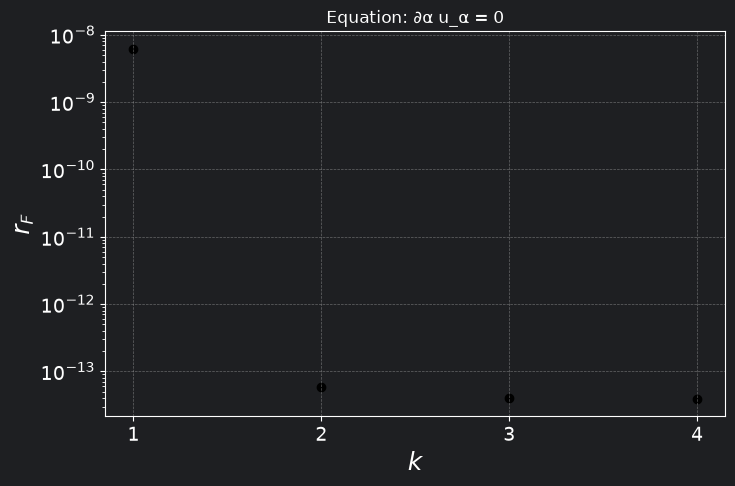

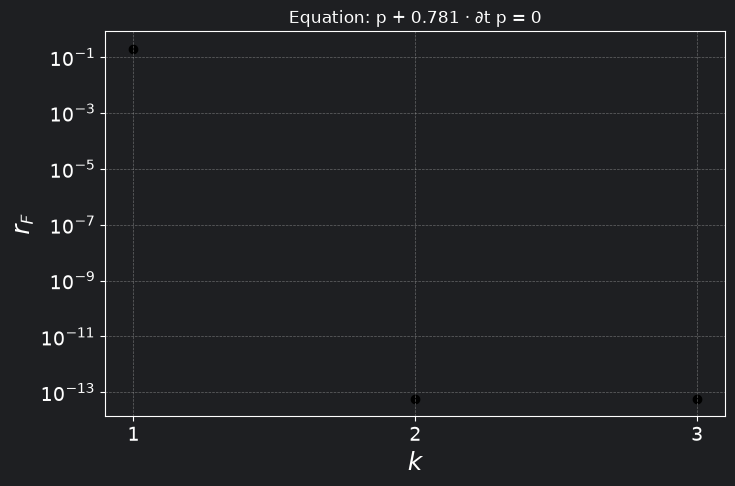

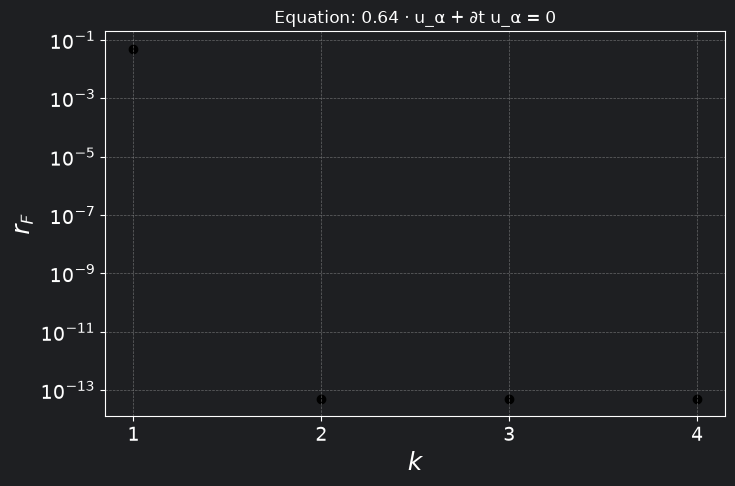

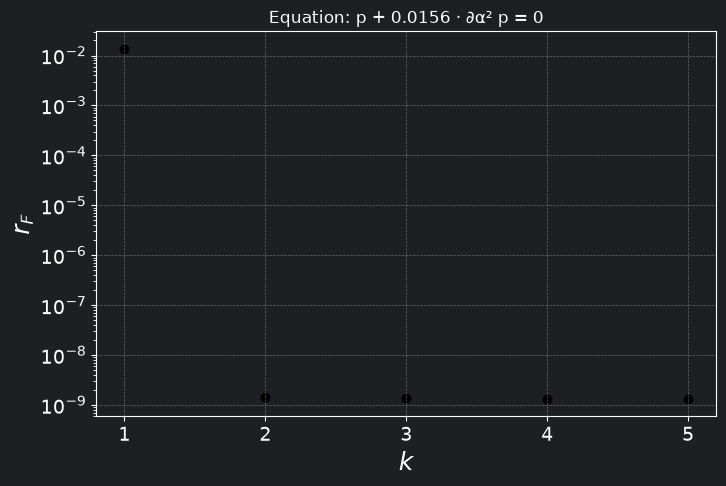

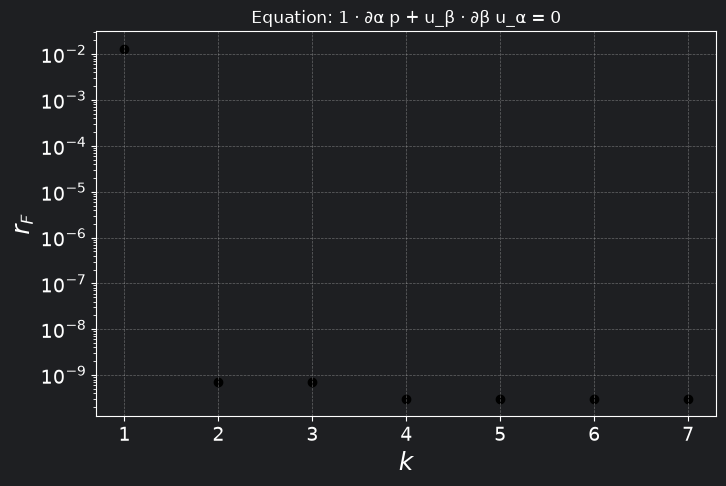

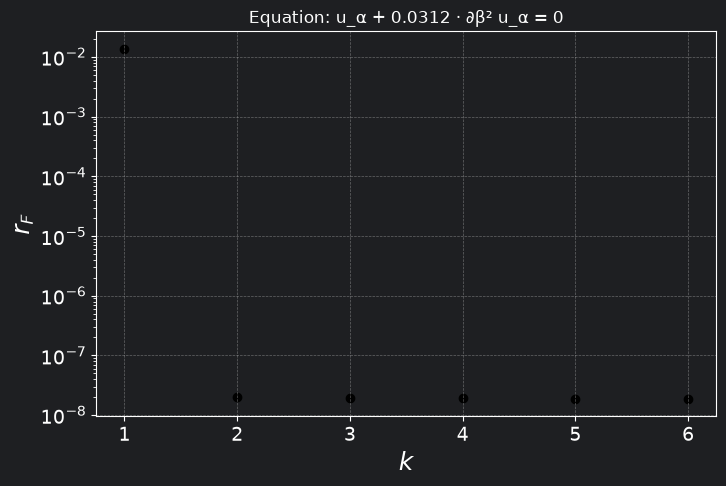

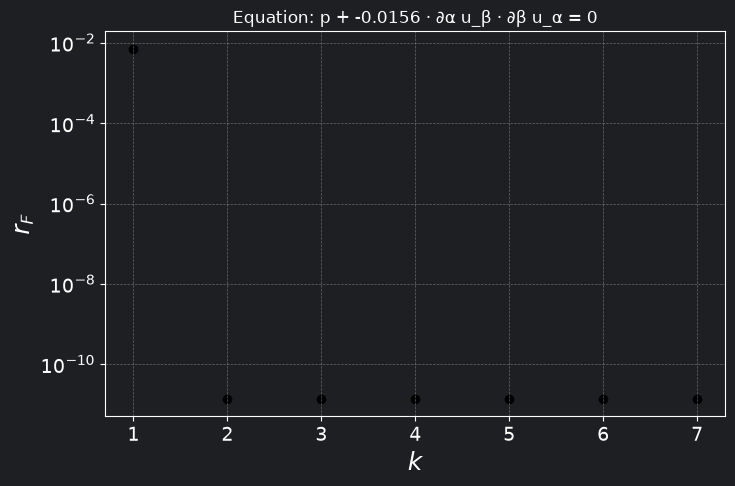

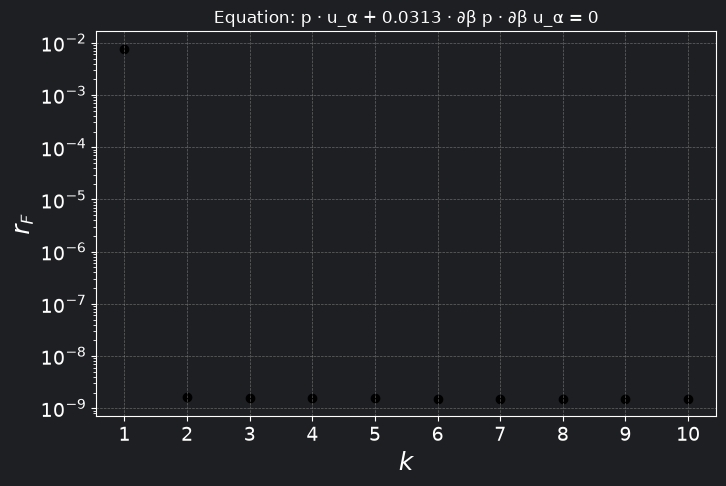

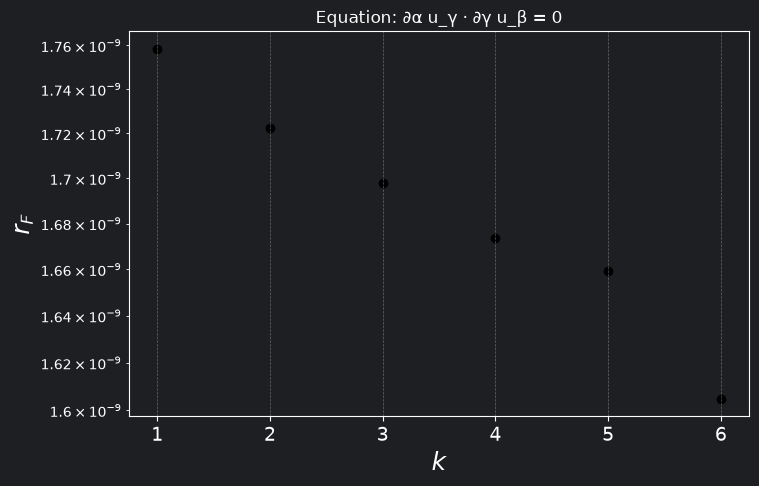

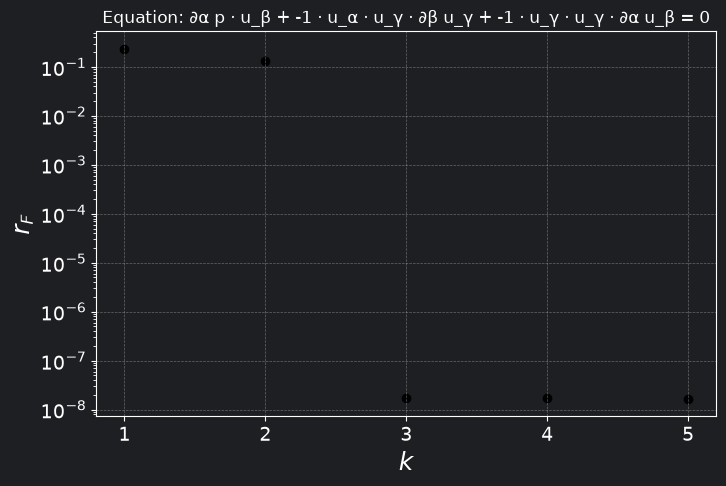

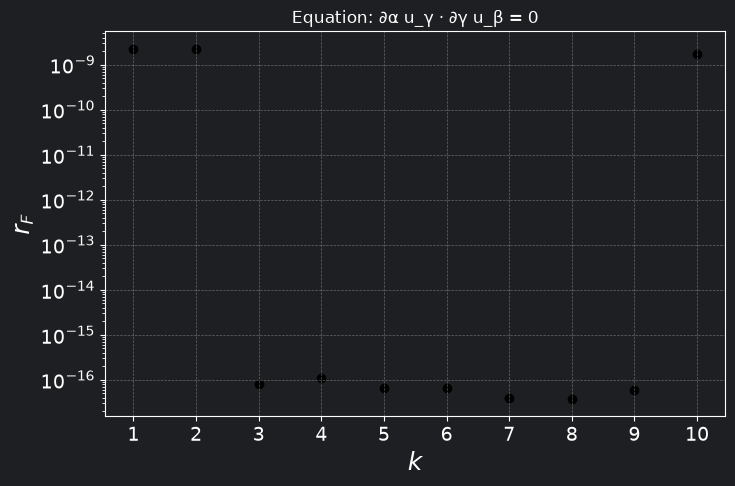

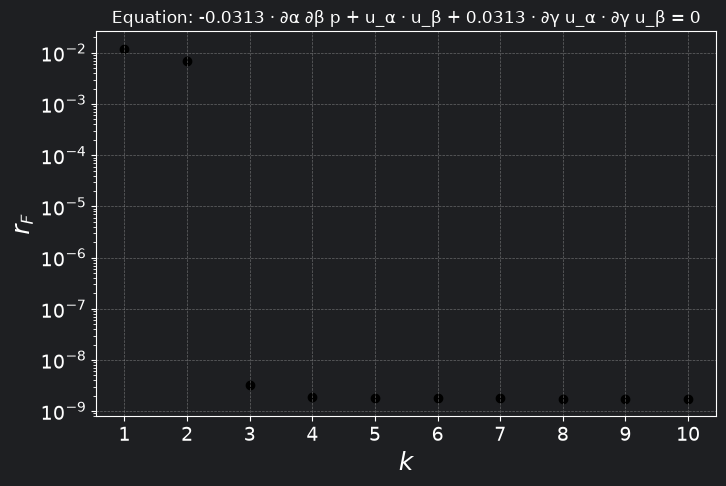

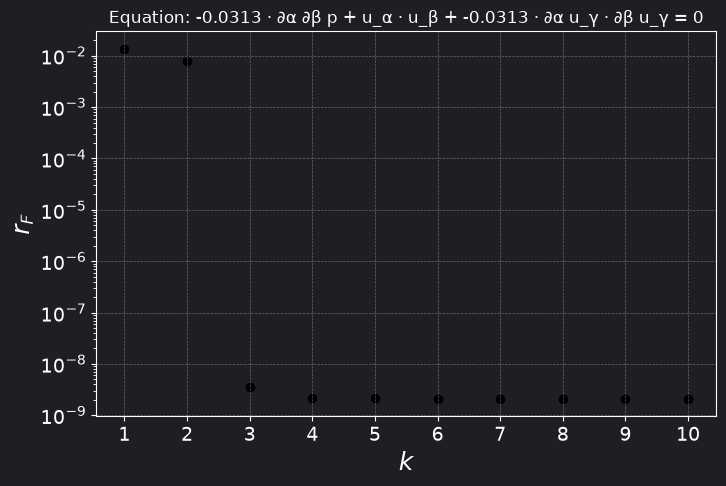

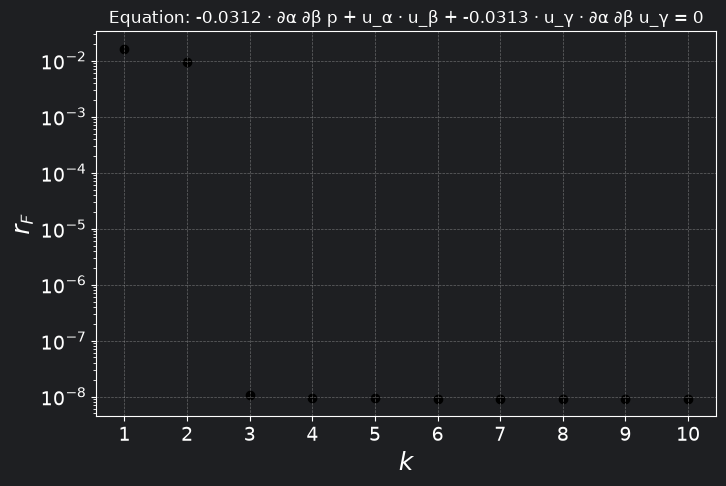

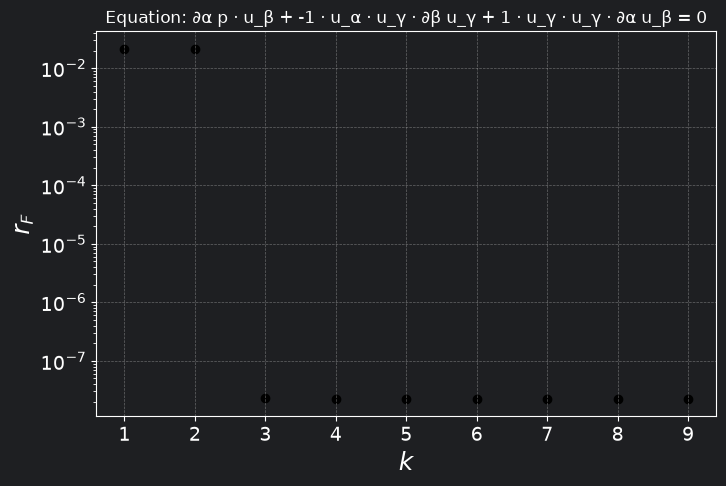

In [32]:
for i, res in enumerate(reg_results):
    all_lambdas = np.array(res.all_lambdas, copy=True)
    all_lambdas[0] = res.lambda1
    all_xis = res.all_xis
    xi_values = res.xi
    sublibrary_terms = res.sublibrary
    equations = []

    equation_string = str(eqs[i].pstr(**{'num_format': '{0:.3g}', 'latex_output': False}))
    
    plt.figure(figsize=(8, 5))
    plt.scatter(range(1, len(all_lambdas) + 1), all_lambdas, color='k')
    plt.yscale("log")

    fs = 18
    fs2 = 14
    plt.xlabel("$k$", fontsize=fs)
    plt.ylabel("$r_F$", fontsize=fs)
    plt.title(f"Equation: {equation_string}")
    plt.xticks(range(1, len(all_lambdas) + 1), fontsize=fs2)
    plt.yticks(fontsize=fs2)
    plt.grid(True, linestyle="--", linewidth=0.5)
    
    plt.show()

### Subdomains of a Gauss grid: `truncated-cg-grid`

The Taylor–Green example obtains each subdomain directly from `SRDataset.grids`. For standalone `int_arr` calls, provide explicit sliced nodes and their integration interval, or supply the parent `num_nodes` to generate a subset of the reference Gauss grid on [-1,1]. The parent-count form uses **reference coordinates**, not an arbitrary physical interval. The Lobatto analogue is `truncated-cc-grid` with `num_intervals`.

The following standalone illustration integrates an unweighted function on a reference subinterval. A full Gauss rule would be unsuitable for this subset.

In [33]:
n_parent = 96
a_sub, b_sub = -0.3, 0.7
nodes_sub = truncated_chebyshev_gauss_nodes(n_parent, a_sub, b_sub)
f_sub = np.exp(nodes_sub)
est = float(int_arr(
    f_sub,
    {0: {"truncated-cg-grid": {"interval": [a_sub, b_sub], "num_nodes": n_parent}}},
))
ref, _ = quad(np.exp, a_sub, b_sub)
print(f'Subgrid: {len(nodes_sub)} of {n_parent} parent nodes')
print(f'estimate={est:.12g}, reference={ref:.12g}, error={abs(est-ref):.3e}')
np.testing.assert_allclose(est, ref, rtol=1e-8)

Subgrid: 33 of 96 parent nodes
estimate=1.27293448677, reference=1.27293448679, error=1.544e-11


### Recommended use of moment matching

`moment_matched_quad_weights` solves the Chebyshev moment system in the coordinates supplied by the caller. Coordinate normalization, suitable nodes, and the matching degree are the caller's responsibility. The equations are valid for arbitrary intervals, but floating-point conditioning can be poor: Chebyshev polynomials grow rapidly outside [-1,1]. Even with 20–100 samples, directly solving in physical coordinates can lose accuracy on constants and other low-degree polynomials.

For a physical interval [a,b], form c=(a+b)/2, H=(b-a)/2, and s=(x-c)/H. Construct the weights in s, evaluate the field at the original physical samples, and include H once for the integration Jacobian. For example:

In [34]:
import numpy as np
from PySPIDER.commons.quadrature_schemes import (
    mapped_chebyshev_nodes, moment_matched_quad_weights,
)

a, b = 2.0, 8.0
c, H = (a + b) / 2, (b - a) / 2
x = mapped_chebyshev_nodes(23, a, b)  # 24 physical samples
s = (x - c) / H
q = moment_matched_quad_weights(s, -1.0, 1.0)
integral = H * np.dot(q, x**2)        # integral of x**2 from 2 to 8 = 168
np.testing.assert_allclose(integral, 168.0, rtol=1e-11)

print(f"Estimated integral: {integral:.12g}; exact integral: 168")


Estimated integral: 168; exact integral: 168


This does not resample the field. Only the coordinates used to construct the quadrature weights change. Full Lobatto or Gauss grids can instead use the corresponding dedicated rule directly.

For a domain-local SPIDER weight W(s), use `int_arr(values, {0: {"moment-matching": {"nodes": x, "interval": [a, b]}}}, weight=weight, domain_local_weight=True)`. That path performs normalization and includes the integration Jacobian internally; do not multiply its result by H again. Set `weight.dxs=[H]` for the physical derivative factors. Dataset evaluation already uses this domain-local convention.

If the intended weight is a function W(x) of the physical coordinate, its transformed integrand is **W(c+Hs) f(c+Hs)**. Replacing it with W(s) changes the integral. One straightforward approach is to integrate the sampled product `W(x) * f(x)` with the unweighted reference weights, including H as in the example; the matching degree must then resolve the whole product.

Normalization does not guarantee a well-conditioned solve for every node set. The default degree is n-1; nearly repeated nodes, near-uniform high-degree grids, and truncated subsets can still amplify roundoff or noise. The low-level function accepts a smaller `degree` for a least-squares moment rule. Choose it using convergence checks and known low-degree integrals; a smaller degree trades polynomial exactness for improved conditioning. More samples at degree n-1 do not necessarily mean more accuracy. Standalone `int_arr` does not currently forward a `degree` option, so use the low-level function when selecting it.

### Discrete coarse-grained fields: match the sampling lattice

This tutorial constructs a continuous field directly on Chebyshev nodes. A discrete `SRDataset` currently coarse-grains particles onto a uniform spatial lattice with spacing `1/cg_res`. Supplying nonuniform spatial coordinates through `grids` does not move those kernel evaluation points or resample the field.

When using discrete data, choose spatial quadrature and differentiation coordinates that match that uniform lattice. Do not label the resulting samples as Chebyshev samples simply by changing `grids` or `schemes_and_options`. A spectral spatial rule requires values actually evaluated or resampled at its nodes, with the corresponding coordinate metadata. Temporal sampling must likewise match the actual input data. Selecting an appropriate rule for the available samples is the caller's responsibility.

#### Original discrete example with Chebyshev time sampling

This repeats the particle model, numerical parameters, library construction, domains, weights, and regression from [02_Discrete.ipynb](02_Discrete.ipynb). The change is **temporal sampling**: evaluate the same constant-velocity trajectories at 250 Chebyshev–Gauss times on `[0, iterations*deltat]`, instead of the original equally spaced times `deltat, ..., iterations*deltat`. Each 30-frame integration window is a subset of that parent grid, so its time axis uses `truncated-cg-grid`. Spatial coarse-graining remains uniform and uses trapezoidal quadrature.

`grids=[None, None, particle_times]` gives PySPIDER the actual physical timestamps for differentiation and domain-local weight scaling. `deltat=1` remains the original nominal time scale; it no longer describes every gap between snapshots. Temporal smoothing is left at its original default of zero. The 30-frame windows have different physical durations, just as the Taylor–Green example's x windows have different physical widths. The remaining settings match the original: L=80, 6400 particles, 250 frames, kernel_sigma=3, cg_res=2, all four irreps, complexity 5, 20 domains of 20×20×30 samples, m=8, qmax=1, and identical regression options.

These cells reuse the original variable names (`srd`, `eqs`, etc.), replacing the continuous example's variables. Run the section in order. Like the original discrete tutorial, the full calculation can take several minutes; the optional animation remains disabled.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation

In [3]:
from PySPIDER.commons.library import Observable
from PySPIDER.discrete.process_library_terms import SRDataset
from PySPIDER.commons.quadrature_schemes import mapped_chebyshev_gauss_nodes


## Generating the dataset
As a toy example, we generate 6400 particles on a square domain with periodic boundaries, which do not interact with each other and move at constant velocities.

In [4]:
L = 80 # size of domain
rho = 1 # density of particles
N = int(rho*L**2) # number of particles
 
deltat = 1.0 # time step
vmax = 4/15 # max particle speed
iterations = 250 # number of time steps

# note that the array axes are (particle #, component of observable, t) - this is the correct input format for SPIDER
positions = np.zeros(shape=(N,2,iterations))
v = np.zeros(shape=(N,2,iterations))
r = np.random.uniform(L/12, 11*L/12, size=(N,2))
v0 = np.random.uniform(-vmax/np.sqrt(2), vmax/np.sqrt(2), size=(N,2))

# Same trajectories, sampled at Chebyshev–Gauss times instead of uniform times.
particle_times = mapped_chebyshev_gauss_nodes(iterations, 0.0, iterations*deltat)
for i, sample_time in enumerate(particle_times):
    positions[:, :, i] = (r + sample_time*v0) % L
    v[:, :, i] = v0


Pay careful attention to the format of the data: they are numpy arrays with axes (particle index, \[optional components\], t), For instance, the particle velocity $v$ corresponds to a 3D numpy array (#, 0=x or 1=y, t), whereas a scalar $s$ should be represented by a 2D array with axes (#, t). Currently, discrete SPIDER best supports datasets in two spatial dimensions, though it can run 3D with some modifications from this tutorial.

If you want, you can generate a movie showing the particles and their velocities over time (requires an FFMpeg installation):

In [5]:
plot = False

if plot:
    fig, ax = plt.subplots(figsize=(6,6)) 
    qv = ax.quiver(r[:,0], r[:,1], v0[:,0], v0[:, 1], np.arctan2(v0[:,0], v0[:,1]), clim=[-np.pi, np.pi])
    ax.axis([0, L, 0, L])
    
    def animate(i):
        if i%10==0:
            print(f"t={i}")
        qv.set_offsets(positions[:, :, i])
        return qv,

    anim = FuncAnimation(fig, animate, np.arange(0, positions.shape[-1]), interval=1, blit=True)
    plt.rcParams['animation.ffmpeg_path'] = '/Users/daniel/Documents/ffmpeg-7.1/ffmpeg' # replace this with your FFMPEG path
    FFwriter = animation.FFMpegWriter(fps=24, codec="libx264")
    anim.save('burgers.mp4', writer=FFwriter, dpi=100)

### Defining and evaluating SPIDER objects

Similarly to the continuous case, let's define an Observable object representing the particle velocity ${\bf v}$ and create a mapping from the observable names to the numpy data arrays.

In [6]:
v_obs = Observable(string='v', rank=1)
observables = [v_obs]
data_dict = {}
data_dict['v'] = v

Let's finish setting up the dataset. Spatial domain sizes are in physical units, and temporal domain sizes count frames, as in the original tutorial. `kernel_sigma=3` and `cg_res=2` are unchanged; spatial coarse-graining uses two samples per physical unit.

The quadrature-specific additions are `grids` and `schemes_and_options`. Axis 2 contains nonuniform timestamps and uses the truncated Gauss-grid rule; axes 0 and 1 retain their matching uniform trapezoidal rule. The integrator obtains the physical time interval from each selected slice, and the weight derivatives use its physical half-width.

In [7]:
world_size = np.array([L, L, iterations]) # dimensions of the dataset in physical units
np.random.seed(1) # set the random seed so the random sample of integration domains is fixed

# initial setup of the dataset object
kernel_sigma = 3
cg_res = 2
# note the additional parameters particle_pos, kernel_sigma, cg_res, and deltat 
# which are not used in the continuous case
srd = SRDataset(world_size=world_size, data_dict=data_dict, particle_pos=positions, observables=observables,
                irreps=SRDataset.all_rank2_irreps(), kernel_sigma=kernel_sigma, cg_res=cg_res, deltat=deltat,
                grids=[None, None, particle_times],
                schemes_and_options={0: 'trapezoidal', 1: 'trapezoidal',
                                     2: 'truncated-cg-grid'})
# another useful parameter is rho_scale, which sets the scaling factor for the 
# coarse-grained density - e.g., rho_scale=100 divides rho by 100

With the caveat of using physical units for the width of the integration domain, the rest of the setup works the same way as in the continuous case.

In [8]:
srd.make_libraries(max_complexity=5, max_rho=2) # include at most two primes in each term
for irrep in srd.irreps:
    print(f"The {irrep} library has {len(srd.libs[irrep].terms)} terms:")
    print(srd.libs[irrep].terms)
    print()

The Rank 0 library has 42 terms:
[ρ, ρ · ρ, ρ · ∂α² ρ, ρ · ∂t ρ, ρ · ∂t ∂α² ρ, ρ · ∂t² ρ, ρ · ∂t³ ρ, ρ · ∂α ρ[v_α], ρ · ∂t ∂α ρ[v_α], ρ · ρ[v_α · v_α], ρ · ∂t ρ[v_α · v_α], ∂α ρ · ∂α ρ, ∂α ρ · ∂t ∂α ρ, ∂α ρ · ρ[v_α], ∂α ρ · ∂t ρ[v_α], ∂α² ρ, ∂α² ρ · ∂t ρ, ∂α² ∂β² ρ, ∂t ρ, ∂t ρ · ∂t ρ, ∂t ρ · ∂t² ρ, ∂t ρ · ∂α ρ[v_α], ∂t ρ · ρ[v_α · v_α], ∂t ∂α ρ · ρ[v_α], ∂t ∂α² ρ, ∂t² ρ, ∂t² ∂α² ρ, ∂t³ ρ, ∂t⁴ ρ, ρ[v_α] · ρ[v_α], ρ[v_α] · ∂t ρ[v_α], ∂α ρ[v_α], ∂α² ∂β ρ[v_β], ∂t ∂α ρ[v_α], ∂t² ∂α ρ[v_α], ρ[v_α · v_α], ∂α ∂β ρ[v_α · v_β], ∂α² ρ[v_β · v_β], ∂t ρ[v_α · v_α], ∂t² ρ[v_α · v_α], ∂α ρ[v_α · v_β · v_β], ρ[v_α · v_α · v_β · v_β]]

The Rank 1 library has 50 terms:
[ρ · ∂α ρ, ρ · ∂α ∂β² ρ, ρ · ∂t ∂α ρ, ρ · ∂t² ∂α ρ, ρ · ρ[v_α], ρ · ∂α ∂β ρ[v_β], ρ · ∂β² ρ[v_α], ρ · ∂t ρ[v_α], ρ · ∂t² ρ[v_α], ρ · ∂α ρ[v_β · v_β], ρ · ∂β ρ[v_α · v_β], ρ · ρ[v_α · v_β · v_β], ∂α ρ, ∂α ρ · ∂β² ρ, ∂β ρ · ∂α ∂β ρ, ∂α ρ · ∂t ρ, ∂α ρ · ∂t² ρ, ∂β ρ · ∂β ρ[v_α], ∂β ρ · ∂α ρ[v_β], ∂α ρ · ∂β ρ[v_β], ∂α ρ · ρ[v_β · v_β], ∂β ρ ·

Tip: using multiple weight functions per domain allows us to spend less time on coarse-graining, which is computationally expensive.

To ensure accuracy of the results, it is important to set a large enough 'pad' parameter so that the coarse-graining doesn't rely on unavailable data outside the domain. For the default coarse-graining function, 4 kernel_sigma is sufficient.

In [9]:
dom_width = 10
dom_time = 30

srd.make_domains(ndomains=20, domain_size=[dom_width, dom_width, dom_time], pad=kernel_sigma*4)
srd.make_weights(m=8, qmax=1)
srd.set_LT_scale(L=1, T=1) # note that this line must go before make_library_matrices

In [10]:
srd.make_library_matrices(debug=False, parallel=True) # this may take a few minutes

### Regression

Regression works exactly the same way as for the continuous version of the problem.

In [11]:
from PySPIDER.commons.identify_models import interleave_identify
from PySPIDER.commons.sparse_reg_bf import Scaler, Initializer, ModelIterator, Residual, Threshold

reg_opts_list = []
for irrep in srd.irreps:
    # for regression we need to construct Scaler, Initializer, ModelIterator, and Threshold objects
    scaler = Scaler(sub_inds=None, char_sizes=srd.libs[irrep].col_weights, row_norms=None, unit_rows=True, train_fraction=1)

    # compute initial k=10 guess via truncated inverse iteration
    init = Initializer(method='power', start_k=10) 
    # complete up to 3 backward-forward passes over 1<=k<=10
    iterator = ModelIterator(max_k=10, backward_forward=True, max_passes=3) 
    res = Residual(residual_type='matrix_relative') # Frobenius residual

    # jump criterion: gamma=1.5, and continue to remove terms until r>delta
    thres = Threshold(threshold_type='jump', gamma=1.5, delta=1e-8)
    
    # put everything together into an options dictionary
    opts = {'scaler': scaler, 'initializer': init, 'residual': res,
            'model_iterator': iterator, 'threshold': thres}
    opts['verbose'] = False # setting to True outputs all of the debug info
    reg_opts_list.append(opts)

# now we can run the regression
eqs, lambdas, reg_results, derived_eqs, excluded_terms = interleave_identify([srd.libs[i] for i in srd.irreps], 
reg_opts_list, threshold=1e-6, report_accuracy=True)

--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 2 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 3 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 3 ---
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 3 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 3 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 4 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 4 ---
--- WORKING ON LIBRARY WITH IRREP Antisym

/Users/patricko/Projects/PySPIDER/src/PySPIDER/commons/sr_utils.py:77: ComplexWarning: Casting complex values to real discards the imaginary part
  x[inds] = smallest_eig(A[np.ix_(inds, inds)])  # work on submatrix with inds


The toy example of non-interacting particles is very nice, since all of moments of the density ${\bf m}$ simply advect:
$$
D{\bf m}=\partial_t {\bf m} + ({\bf v} \cdot \nabla){\bf m} = 0
$$ 
The physical relations to look for in the regression output include mass conservation $$\partial_t \rho + \partial_\alpha \rho[v_\alpha] = 0$$ and the multidimensional inviscid Burgers' equation $$\partial_t \rho[v_\alpha] + \partial_\beta \rho[v_\alpha v_\beta] = 0.$$

The numerical and regression parameters above are deliberately unchanged from `02_Discrete.ipynb`. Changing the timestamps changes quadrature errors and which relations pass the regression thresholds; the initial particle realization is also random, as in the original. In the saved execution, regression identified a rank-two identity but did not recover the mass and momentum conservation laws at the configured threshold. Successful execution alone is not evidence that those laws have been recovered: inspect the reported equations and residuals. No thresholds or resolutions have been adjusted to force their recovery.


### Takeaways

1. The Taylor–Green field, library construction, regression options, and output analysis follow `01_Continuous.ipynb`; nonuniform sampling requires matching quadrature and coordinate metadata.
2. Full mapped Lobatto/Gauss rules need their complete node sets. Use the corresponding truncated rule for subdomains, as in the 40-point x windows above.
3. `SRDataset.grids` carries physical sample coordinates. `Weight.dxs` carries physical support half-widths for the chain rule, not sample spacings.
4. Standalone moment matching uses the supplied coordinates. Normalize them, include the Jacobian once, and select a degree appropriate to the node set.
5. Check the discovered coefficients and residuals against known Taylor–Green identities. Matching the quadrature rule is necessary, but adequate resolution and well-conditioned moments still matter.